In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import glob
import math
import os
from tqdm import tqdm
import random
import re

In [3]:
# Define a range of thresholds from the minimum to the maximum score
def calculate_thresholds(genuine_scores, impostor_scores, num_thresholds=100):
    min_score = min(min(genuine_scores), min(impostor_scores))
    max_score = max(max(genuine_scores), max(impostor_scores))
    return np.linspace(min_score, max_score, num_thresholds)

# Compute FAR, FRR, and EER with Bootstrapping
def calculate_far_frr(threshold, genuine_scores, impostor_scores):
    far = np.sum(np.array(impostor_scores) >= threshold) / len(impostor_scores)
    frr = np.sum(np.array(genuine_scores) < threshold) / len(genuine_scores)
    return far, frr

def bootstrap_eer(thresholds, genuine_scores, impostor_scores, n_bootstrap=1000):
    far_values = []
    frr_values = []
    auc_values = []

    for _ in tqdm(range(n_bootstrap), desc="Bootstrapping Progress"):
        genuine_sample = [random.choice(genuine_scores) for _ in range(len(genuine_scores))]
        impostor_sample = [random.choice(impostor_scores) for _ in range(len(impostor_scores))]

        fars = []
        frrs = []
        for threshold in thresholds:
            far, frr = calculate_far_frr(threshold, genuine_sample, impostor_sample)
            fars.append(far)
            frrs.append(frr)

        roc_auc = auc(fars, 1 - np.array(frrs))
        auc_values.append(roc_auc)

        far_values.append(fars)
        frr_values.append(frrs)

    far_values = np.array(far_values)
    frr_values = np.array(frr_values)
    auc_values = np.array(auc_values)

    return far_values, frr_values, auc_values

def plot_single_roc_with_uncertainty(csv_files, title, save, n_bootstrap=1000):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    plt.figure(figsize=(7, 5))

    # Separate files by technique
    mask_ddpg_files = [file for file in csv_files if 'cpp-deid' not in file[0]]
    cpp_deid_files = [file for file in csv_files if 'cpp-deid' in file[0]]

    # Process Mask-DDPG files: compute and store the metrics for each file
    mask_results = []
    for path, label in mask_ddpg_files:
        data = pd.read_csv(path)
        genuine_scores = data[data['ground_truth'] == True]['cossim'].tolist()
        impostor_scores = data[data['ground_truth'] == False]['cossim'].tolist()

        # Compute thresholds and bootstrap metrics
        thresholds = calculate_thresholds(genuine_scores, impostor_scores)
        far_values, frr_values, auc_values = bootstrap_eer(thresholds, genuine_scores, impostor_scores, n_bootstrap)

        mean_far = np.mean(far_values, axis=0)
        mean_frr = np.mean(frr_values, axis=0)
        far_std = np.std(far_values, axis=0)
        frr_std = np.std(frr_values, axis=0)

        roc_auc = np.mean(auc_values)
        auc_uncertainty = np.std(auc_values)

        mask_results.append({
            'path': path,
            'label': label,
            'mean_far': mean_far,
            'mean_frr': mean_frr,
            'far_std': far_std,
            'frr_std': frr_std,
            'roc_auc': roc_auc,
            'auc_uncertainty': auc_uncertainty,
        })

    # Sort Mask-DDPG results by decreasing AUC
    mask_results_sorted = sorted(mask_results, key=lambda x: x['roc_auc'], reverse=True)

    # Generate color mapping for Mask-DDPG curves
    colors_mask_ddpg = plt.cm.plasma(np.linspace(0, 1, len(mask_results_sorted)))

    # Plot Mask-DDPG curves in sorted order
    for idx, result in enumerate(mask_results_sorted):
        plt.plot(result['mean_far'], 1 - result['mean_frr'], color=colors_mask_ddpg[idx], lw=1.5,
                 label=f"{result['label']}; AUC={result['roc_auc']:.2f}")
        plt.fill_between(result['mean_far'], 1 - result['mean_frr'] - result['frr_std'],
                         1 - result['mean_frr'] + result['frr_std'], alpha=0.2, color=colors_mask_ddpg[idx])

    # Process CPP-DeID files: compute and store the metrics for each file
    cpp_deid_results = []
    for path, label in cpp_deid_files:
        data = pd.read_csv(path)
        genuine_scores = data[data['ground_truth'] == True]['cossim'].tolist()
        impostor_scores = data[data['ground_truth'] == False]['cossim'].tolist()

        thresholds = calculate_thresholds(genuine_scores, impostor_scores)
        far_values, frr_values, auc_values = bootstrap_eer(thresholds, genuine_scores, impostor_scores, n_bootstrap)

        mean_far = np.mean(far_values, axis=0)
        mean_frr = np.mean(frr_values, axis=0)
        far_std = np.std(far_values, axis=0)
        frr_std = np.std(frr_values, axis=0)

        roc_auc = np.mean(auc_values)
        auc_uncertainty = np.std(auc_values)

        cpp_deid_results.append({
            'path': path,
            'label': label,
            'mean_far': mean_far,
            'mean_frr': mean_frr,
            'far_std': far_std,
            'frr_std': frr_std,
            'roc_auc': roc_auc,
            'auc_uncertainty': auc_uncertainty,
        })

    # Sort CPP-DeID results by decreasing AUC
    cpp_deid_results_sorted = sorted(cpp_deid_results, key=lambda x: x['roc_auc'], reverse=True)

    # Generate color mapping for CPP-DeID curves
    colors_cpp_deid = plt.cm.cividis(np.linspace(0, 1, len(cpp_deid_results_sorted)))

    # Plot CPP-DeID curves in sorted order
    for idx, result in enumerate(cpp_deid_results_sorted):
        plt.plot(result['mean_far'], 1 - result['mean_frr'], color=colors_cpp_deid[idx], lw=1.5,
                 label=f"{result['label']}; AUC={result['roc_auc']:.2f}")
        plt.fill_between(result['mean_far'], 1 - result['mean_frr'] - result['frr_std'],
                         1 - result['mean_frr'] + result['frr_std'], alpha=0.2, color=colors_cpp_deid[idx])

    # Plot the diagonal reference line
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey', lw=1)

    # Customize plot appearance
    plt.xlabel('False acceptance rate (FAR)')
    plt.ylabel('Verification rate (VER)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save and display the figure
    plt.savefig(f"{save}.pdf", dpi=300, format="pdf", bbox_inches="tight")
    plt.savefig(f"{save}.svg", dpi=300, format="svg", bbox_inches="tight")
    print(f"Figure saved as {save}.pdf")
    print(f"Figure saved as {save}.svg")
    plt.show()

def get_files_with_pattern(directory, pattern):
    matching_files = []
    regex = re.compile(pattern)
    
    for root, _, files in os.walk(directory):
        for file in files:
            if regex.search(file):  # Check if filename matches regex
                matching_files.append(os.path.join(root, file))
    
    return matching_files
def is_number(s: str) -> bool:
    try:
        float(s)
        return True
    except ValueError:
        return False

[('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.0_gauss_GauDeiDiff.csv', '$\\lambda$ = 0.0 gauss_GauDeiDiff'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.4_mean_GauDeiDiff.csv', '$\\lambda$ = 0.4 mean_GauDeiDiff'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.0_Lapl_GauDeiDiff.csv', '$\\lambda$ = 0.0 Lapl_GauDeiDiff'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_fadm.csv', 'fadm'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.9_mean_GauDeiDiff.csv', '$\\lambda$ = 0.9 mean_GauDeiDiff'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.3_mean_GauDeiDiff.csv', '$\\lambda$ = 0.3 mean_GauDeiDiff'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/res

Bootstrapping Progress: 100%|██████████| 300/300 [00:11<00:00, 27.01it/s]


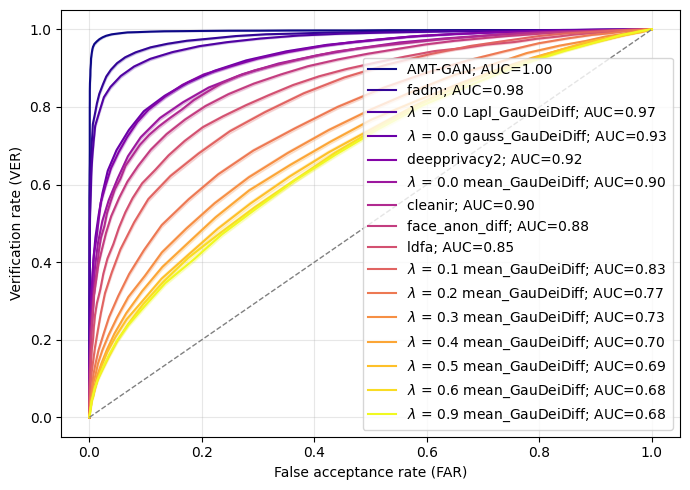

In [27]:
directory = "/home/tico/Desktop/master_research/deid-toolkit/root_dir/results"
pattern = r"adaface_optimized_xm2vts_aligned_(?!.*MaskDDPG).*"
eval_tech = 'adaface_optimized'
dataset_name = 'xm2vts_aligned'
matching_files = get_files_with_pattern(directory, pattern)
prefix       = f"{eval_tech}_{dataset_name}_"

tuple_list = []
for filepath in matching_files:
    fn = os.path.basename(filepath)
    name, _ = os.path.splitext(fn)

    if not name.startswith(prefix):
        # fallback if you didn’t match the pattern
        tuple_list.append((filepath, name))
        continue

    # strip the prefix off, then split
    suffix = name[len(prefix):]          # e.g. "0.1234_some_other_stuff"
    parts = suffix.split('_')            # ["0.1234", "some", "other", "stuff"]
    root = parts[0]                      # "0.1234"
    rest = parts[1:]                     # ["some","other","stuff"]

    if is_number(root):
        val = float(root)
        # λ with 3 decimal places; change .3f → .10f if you want more precision
        lambda_ = r'$\lambda$'
        lambda_str = f"{lambda_} = {val:.1f}"
        if rest:
            lambda_str += " " + "_".join(rest)
        display_name = lambda_str
    else:
        display_name = suffix

    tuple_list.append((filepath, display_name))

print(tuple_list)
# Print the list of tuples
plot_single_roc_with_uncertainty(tuple_list,'ROC of xm2vts, adaface embeddings SOTA','GauDeiDiff', n_bootstrap=300)

[('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_1.0_old_MaskDDPG.csv', '$\\lambda$ = 1.00_old'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_1.0_oldmask_MaskDDPG.csv', '$\\lambda$ = 1.00_oldmask'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_1.0_oldbbox_MaskDDPG.csv', '$\\lambda$ = 1.00_oldbbox')]


Bootstrapping Progress:   0%|          | 0/500 [00:00<?, ?it/s]

Bootstrapping Progress: 100%|██████████| 500/500 [00:18<00:00, 26.70it/s]


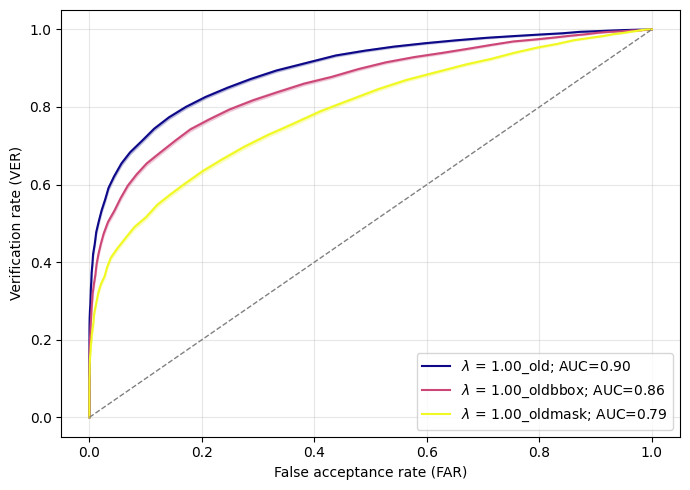

In [6]:
directory = "/home/tico/Desktop/master_research/deid-toolkit/root_dir/results"
# Updated Regex pattern to avoid filenames containing "GauDeiDiff"
technique = 'MaskDDPG'
dataset_name = 'xm2vts_aligned'  
eval_tech = 'adaface_optimized'
pattern = rf"^{eval_tech}_{dataset_name}_(?=.*MaskDDPG).*$"
matching_files = get_files_with_pattern(directory, pattern)
prefix       = f"{eval_tech}_{dataset_name}_"

tuple_list = []
for filepath in matching_files:
    fn = os.path.basename(filepath)
    name, _ = os.path.splitext(fn)

    if not name.startswith(prefix):
        # fallback if you didn’t match the pattern
        tuple_list.append((filepath, name))
        continue

    # strip the prefix off, then split
    suffix = name[len(prefix):]          # e.g. "0.1234_some_other_stuff"
    parts = suffix.split('_')            # ["0.1234", "some", "other", "stuff"]
    root = parts[0]                      # "0.1234"
    rest = parts[1:]                     # ["some","other","stuff"]

    if is_number(root):
        val = float(root)
        # λ with 3 decimal places; change .3f → .10f if you want more precision
        lambda_ = r'$\lambda$'
        if len(rest) > 1:
            lambda_str = f"{lambda_} = {val:.2f}_{rest[0]}"
        else:
            lambda_str = f"{lambda_} = {val:.2f}"
        '''if rest:
            lambda_str += " " + "_".join(rest)'''
        display_name = lambda_str
    else:
        display_name = suffix

    tuple_list.append((filepath, display_name))

print(tuple_list)

# Print the list of tuples and plot the ROC
plot_single_roc_with_uncertainty(tuple_list, f'ROC of {dataset_name}, adaface embeddings SOTA', 'MaskDDPG_Only', n_bootstrap=500)

[('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_1.0_MaskDDPG.csv', '$\\lambda$ = 1.00'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_0.8_MaskDDPG.csv', '$\\lambda$ = 0.80'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_0.9_MaskDDPG.csv', '$\\lambda$ = 0.90')]


Bootstrapping Progress: 100%|██████████| 500/500 [00:03<00:00, 131.28it/s]


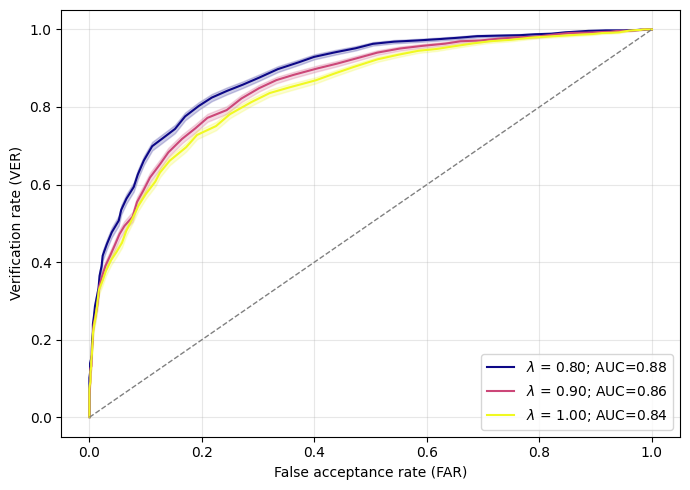

In [3]:
directory = "/home/tico/Desktop/master_research/deid-toolkit/root_dir/results"
# Updated Regex pattern to avoid filenames containing "GauDeiDiff"
technique = 'MaskDDPG'
dataset_name = 'rafd'  
eval_tech = 'adaface_optimized'
pattern = rf"^{eval_tech}_{dataset_name}_(?=.*MaskDDPG).*$"
matching_files = get_files_with_pattern(directory, pattern)
prefix       = f"{eval_tech}_{dataset_name}_"

tuple_list = []
for filepath in matching_files:
    fn = os.path.basename(filepath)
    name, _ = os.path.splitext(fn)

    if not name.startswith(prefix):
        # fallback if you didn’t match the pattern
        tuple_list.append((filepath, name))
        continue

    # strip the prefix off, then split
    suffix = name[len(prefix):]          # e.g. "0.1234_some_other_stuff"
    parts = suffix.split('_')            # ["0.1234", "some", "other", "stuff"]
    root = parts[0]                      # "0.1234"
    rest = parts[1:]                     # ["some","other","stuff"]

    if is_number(root):
        val = float(root)
        # λ with 3 decimal places; change .3f → .10f if you want more precision
        lambda_ = r'$\lambda$'
        if len(rest) > 1:
            lambda_str = f"{lambda_} = {val:.2f}_{rest[0]}"
        else:
            lambda_str = f"{lambda_} = {val:.2f}"
        '''if rest:
            lambda_str += " " + "_".join(rest)'''
        display_name = lambda_str
    else:
        display_name = suffix

    tuple_list.append((filepath, display_name))

print(tuple_list)

# Print the list of tuples and plot the ROC
plot_single_roc_with_uncertainty(tuple_list, f'ROC of {dataset_name}, adaface embeddings SOTA', 'MaskDDPG_Only', n_bootstrap=500)

[('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_AMT-GAN.csv', 'AMT-GAN'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_cleanir.csv', 'cleanir'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_1.0_MaskDDPG.csv', '$\\lambda$ = 1.0 MaskDDPG'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_ldfa.csv', 'ldfa'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_deepprivacy2.csv', 'deepprivacy2'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_face_anon_diff.csv', 'face_anon_diff'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_0.8_MaskDDPG.csv', '$\\lambda$ = 0.8 MaskDDPG'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_rafd_0.5_MaskDDPG.csv', '$\\lambda$ = 

Bootstrapping Progress: 100%|██████████| 300/300 [00:02<00:00, 136.15it/s]


Figure saved as MaskDDPG_rafd.pdf
Figure saved as MaskDDPG_rafd.svg


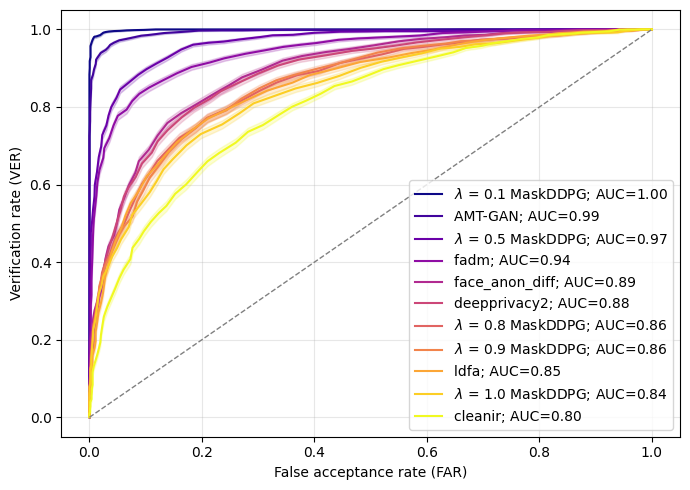

In [8]:
directory = "/home/tico/Desktop/master_research/deid-toolkit/root_dir/results"
# Updated Regex pattern to avoid filenames containing "GauDeiDiff"
technique = 'MaskDDPG'
dataset_name = 'rafd'  
eval_tech = 'adaface_optimized'
pattern = rf"^{eval_tech}_{dataset_name}_(?!.*GauDeiDiff).*$"
matching_files = get_files_with_pattern(directory, pattern)
prefix       = f"{eval_tech}_{dataset_name}_"

tuple_list = []
for filepath in matching_files:
    fn = os.path.basename(filepath)
    name, _ = os.path.splitext(fn)

    if not name.startswith(prefix):
        # fallback if you didn’t match the pattern
        tuple_list.append((filepath, name))
        continue

    # strip the prefix off, then split
    suffix = name[len(prefix):]          # e.g. "0.1234_some_other_stuff"
    parts = suffix.split('_')            # ["0.1234", "some", "other", "stuff"]
    root = parts[0]                      # "0.1234"
    rest = parts[1:]                     # ["some","other","stuff"]

    if is_number(root):
        val = float(root)
        # λ with 3 decimal places; change .3f → .10f if you want more precision
        lambda_ = r'$\lambda$'
        lambda_str = f"{lambda_} = {val:.1f}"
        if rest:
            lambda_str += " " + "_".join(rest)
        display_name = lambda_str
    else:
        display_name = suffix

    tuple_list.append((filepath, display_name))

print(tuple_list)
# Print the list of tuples
plot_single_roc_with_uncertainty(tuple_list,f'ROC of {dataset_name}, adaface embeddings SOTA',technique+"_"+dataset_name, n_bootstrap=300)

[('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_fadm.csv', 'fadm'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_1.0_MaskDDPG.csv', '$\\lambda$ = 1.0 MaskDDPG'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_cleanir.csv', 'cleanir'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_face_anon_diff.csv', 'face_anon_diff'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_AMT-GAN.csv', 'AMT-GAN'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_ldfa.csv', 'ldfa'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_deepprivacy2.csv', 'deepprivacy2')]


Bootstrapping Progress:   0%|          | 0/300 [00:00<?, ?it/s]

Bootstrapping Progress: 100%|██████████| 300/300 [00:11<00:00, 26.17it/s]


Figure saved as MaskDDPG_xm2vts_aligned.pdf
Figure saved as MaskDDPG_xm2vts_aligned.svg


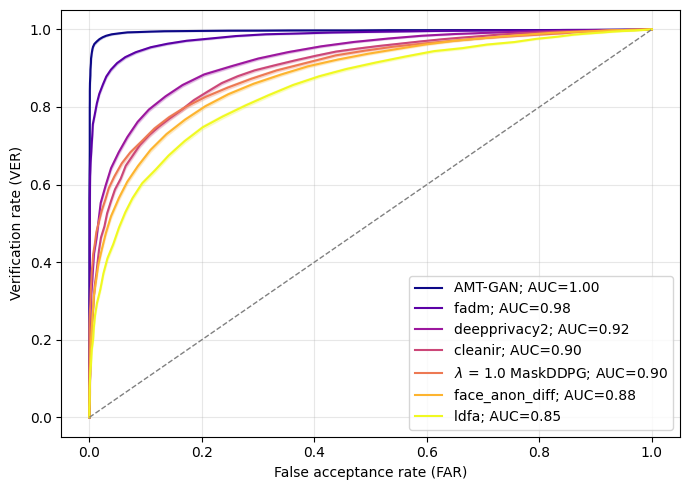

In [7]:
directory = "/home/tico/Desktop/master_research/deid-toolkit/root_dir/results"
# Updated Regex pattern to avoid filenames containing "GauDeiDiff"
technique = 'MaskDDPG'
dataset_name = 'xm2vts_aligned'  
eval_tech = 'adaface_optimized'
pattern = rf"^{eval_tech}_{dataset_name}_(?!.*GauDeiDiff).*$"
matching_files = get_files_with_pattern(directory, pattern)
prefix       = f"{eval_tech}_{dataset_name}_"

tuple_list = []
for filepath in matching_files:
    fn = os.path.basename(filepath)
    name, _ = os.path.splitext(fn)

    if not name.startswith(prefix):
        # fallback if you didn’t match the pattern
        tuple_list.append((filepath, name))
        continue

    # strip the prefix off, then split
    suffix = name[len(prefix):]          # e.g. "0.1234_some_other_stuff"
    parts = suffix.split('_')            # ["0.1234", "some", "other", "stuff"]
    root = parts[0]                      # "0.1234"
    rest = parts[1:]                     # ["some","other","stuff"]

    if is_number(root):
        val = float(root)
        # λ with 3 decimal places; change .3f → .10f if you want more precision
        lambda_ = r'$\lambda$'
        lambda_str = f"{lambda_} = {val:.1f}"
        if rest:
            lambda_str += " " + "_".join(rest)
        display_name = lambda_str
    else:
        display_name = suffix

    tuple_list.append((filepath, display_name))

print(tuple_list)
# Print the list of tuples
plot_single_roc_with_uncertainty(tuple_list,f'ROC of {dataset_name}, adaface embeddings SOTA',technique+"_"+dataset_name, n_bootstrap=300)

[('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.9_MaskDDPG.csv', '$\\lambda$ = 0.90 MaskDDPG'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_fadm.csv', 'fadm'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.88_MaskDDPG.csv', '$\\lambda$ = 0.88 MaskDDPG'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.7_MaskDDPG.csv', '$\\lambda$ = 0.70 MaskDDPG'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.84_MaskDDPG.csv', '$\\lambda$ = 0.84 MaskDDPG'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.8_MaskDDPG.csv', '$\\lambda$ = 0.80 MaskDDPG'), ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_xm2vts_aligned_0.82_MaskDDPG.csv', '$\\lam

Bootstrapping Progress: 100%|██████████| 300/300 [00:11<00:00, 27.14it/s]


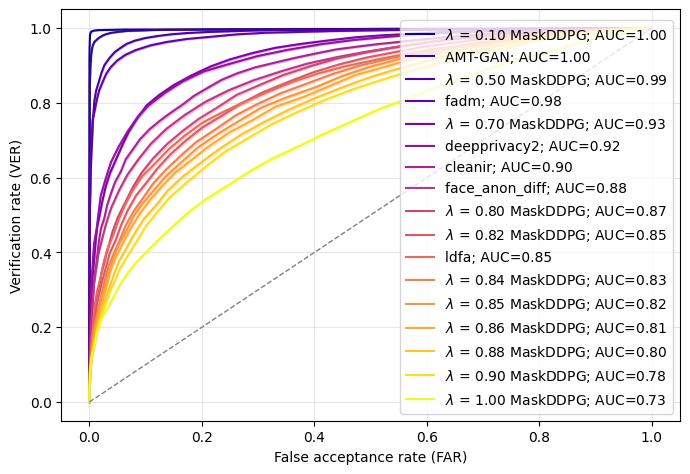

In [ ]:
directory = "/home/tico/Desktop/master_research/deid-toolkit/root_dir/results"
# Updated Regex pattern to avoid filenames containing "GauDeiDiff"
pattern = r"adaface_optimized_xm2vts_aligned_(?!.*GauDeiDiff).*"  
eval_tech = 'adaface_optimized'
dataset_name = 'xm2vts_aligned'
matching_files = get_files_with_pattern(directory, pattern)
prefix       = f"{eval_tech}_{dataset_name}_"

tuple_list = []
for filepath in matching_files:
    fn = os.path.basename(filepath)
    name, _ = os.path.splitext(fn)

    if not name.startswith(prefix):
        # fallback if you didn’t match the pattern
        tuple_list.append((filepath, name))
        continue

    # strip the prefix off, then split
    suffix = name[len(prefix):]          # e.g. "0.1234_some_other_stuff"
    parts = suffix.split('_')            # ["0.1234", "some", "other", "stuff"]
    root = parts[0]                      # "0.1234"
    rest = parts[1:]                     # ["some","other","stuff"]

    if is_number(root):
        val = float(root)
        # λ with 3 decimal places; change .3f → .10f if you want more precision
        lambda_ = r'$\lambda$'
        lambda_str = f"{lambda_} = {val:.2f}"
        if rest:
            lambda_str += " " + "_".join(rest)
        display_name = lambda_str
    else:
        display_name = suffix

    tuple_list.append((filepath, display_name))

print(tuple_list)

# Print the list of tuples and plot the ROC
plot_single_roc_with_uncertainty(tuple_list, 'ROC of xm2vts, adaface embeddings SOTA', 'MaskDDPG', n_bootstrap=300)


Bootstrapping Progress: 100%|██████████| 1000/1000 [00:13<00:00, 71.91it/s]


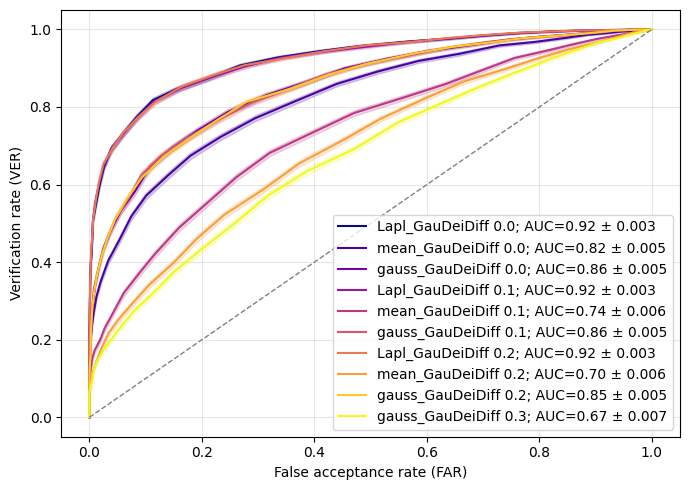

In [4]:
# Set the directory path for your CSV files
results_dir_path = "/home/tico/Desktop/master_research/deid-toolkit/root_dir/results"
csv_files = [#pairs: path, label
    (f'{results_dir_path}/adaface_optimized_LFW_benchmark_0.0_Lapl_GauDeiDiff.csv','Lapl_GauDeiDiff 0.0'),
    (f'{results_dir_path}/adaface_optimized_LFW_benchmark_0.0_mean_GauDeiDiff.csv','mean_GauDeiDiff 0.0'),
    (f'{results_dir_path}/adaface_optimized_LFW_benchmark_0.0_gauss_GauDeiDiff.csv','gauss_GauDeiDiff 0.0'),
    (f'{results_dir_path}/adaface_optimized_LFW_benchmark_0.1_Lapl_GauDeiDiff.csv','Lapl_GauDeiDiff 0.1'),
    (f'{results_dir_path}/adaface_optimized_LFW_benchmark_0.1_mean_GauDeiDiff.csv','mean_GauDeiDiff 0.1'),
    (f'{results_dir_path}/adaface_optimized_LFW_benchmark_0.1_gauss_GauDeiDiff.csv','gauss_GauDeiDiff 0.1'),
    (f'{results_dir_path}/adaface_optimized_LFW_benchmark_0.2_Lapl_GauDeiDiff.csv','Lapl_GauDeiDiff 0.2'),
    (f'{results_dir_path}/adaface_optimized_LFW_benchmark_0.2_mean_GauDeiDiff.csv','mean_GauDeiDiff 0.2'),
    (f'{results_dir_path}/adaface_optimized_LFW_benchmark_0.2_gauss_GauDeiDiff.csv','gauss_GauDeiDiff 0.2'),
    (f'{results_dir_path}/adaface_optimized_LFW_benchmark_0.3_mean_GauDeiDiff.csv','gauss_GauDeiDiff 0.3')
]
plot_single_roc_with_uncertainty(csv_files,'ROC of LFW_benchmark, adaface embeddings GauDeiDiff at [0.0; 0.1; 0.2]','GauDeiDiff', n_bootstrap=1000)


Bootstrapping Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping Progress: 100%|██████████| 1000/1000 [00:13<00:00, 73.56it/s]


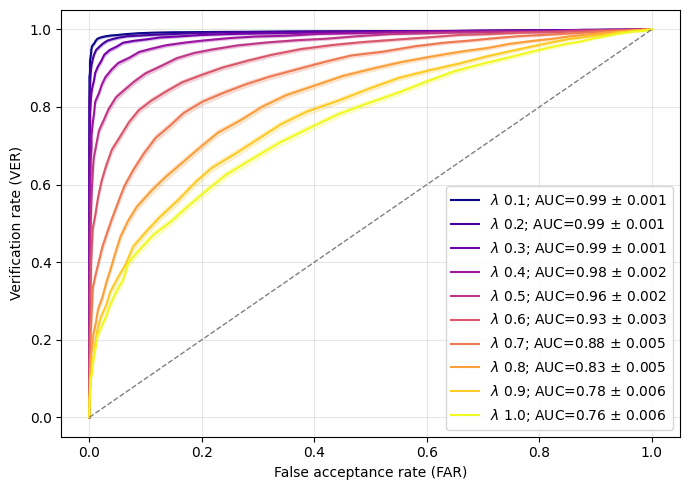

In [2]:
# Set the directory path for your CSV files
csv_files = [#pairs: path, label
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.1_MaskDDPG.csv',r'$\lambda$ 0.1'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.2_MaskDDPG.csv',r'$\lambda$ 0.2'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.3_MaskDDPG.csv',r'$\lambda$ 0.3'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.4_MaskDDPG.csv',r'$\lambda$ 0.4'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.5_MaskDDPG.csv',r'$\lambda$ 0.5'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.6_MaskDDPG.csv',r'$\lambda$ 0.6'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.7_MaskDDPG.csv',r'$\lambda$ 0.7'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.8_MaskDDPG.csv',r'$\lambda$ 0.8'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.9_MaskDDPG.csv',r'$\lambda$ 0.9'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_1.0_MaskDDPG.csv',r'$\lambda$ 1.0')
]
plot_single_roc_with_uncertainty(csv_files,'ROC curves, for MaskDDPG over LFW dataset','MDDPG_AUC', n_bootstrap=1000)


Bootstrapping Progress: 100%|██████████| 1000/1000 [00:16<00:00, 60.09it/s]


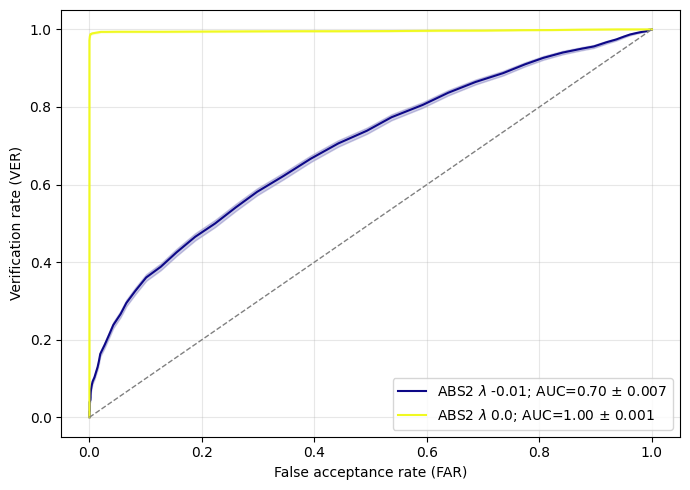

In [5]:
# Set the directory path for your CSV files
csv_files = [#pairs: path, label
    ('/home/tico/Desktop/master_research/DeiDDPG/verification_scores_maskDDPG/ablations/adaface_optimized_LFW_benchmark_-0_01_MaskDDPG.csv',r'ABS2 $\lambda$ -0.01'),
    ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_LFW_benchmark_0.0_MaskDDPG.csv',r'ABS2 $\lambda$ 0.0')
]
plot_single_roc_with_uncertainty(csv_files,'ROC curves, for MaskDDPG over LFW dataset','MDDPG_AUC', n_bootstrap=1000)

Bootstrapping Progress: 100%|██████████| 1000/1000 [00:16<00:00, 60.70it/s]


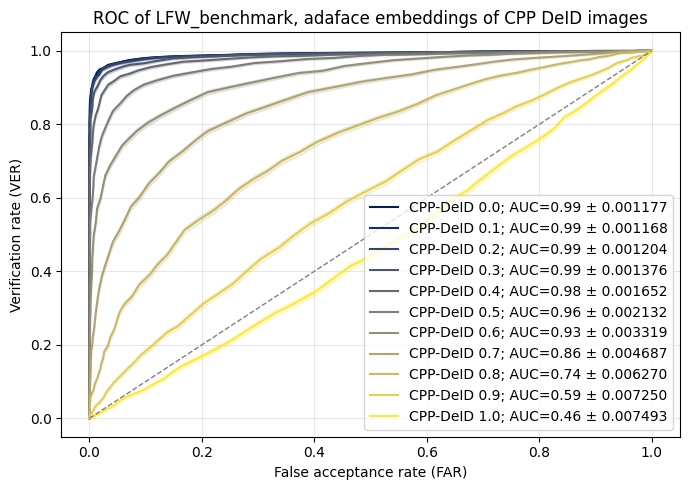

In [12]:
csv_files = [#pairs: path, label
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_1.0_cpp-deid.csv','CPP-DeID 0.0'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.9_cpp-deid.csv','CPP-DeID 0.1'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.8_cpp-deid.csv','CPP-DeID 0.2'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.7_cpp-deid.csv','CPP-DeID 0.3'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.6_cpp-deid.csv','CPP-DeID 0.4'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.5_cpp-deid.csv','CPP-DeID 0.5'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.4_cpp-deid.csv','CPP-DeID 0.6'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.3_cpp-deid.csv','CPP-DeID 0.7'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.2_cpp-deid.csv','CPP-DeID 0.8'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.1_cpp-deid.csv','CPP-DeID 0.9'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.0_cpp-deid.csv','CPP-DeID 1.0'),
]
plot_single_roc_with_uncertainty(csv_files,'ROC of LFW_benchmark, adaface embeddings of CPP DeID images', n_bootstrap=1000)

In [ ]:
csv_files = [#pairs: path, label
    ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_CPLFW_benchmark_aligned_GDDPG.csv','CPLFW_benchmark_aligned_GDDPG'),
    ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_CPLFW_benchmark_aligned_AMT-GAN.csv','CPLFW_benchmark_aligned_AMT-GAN'),
    ('/home/tico/Desktop/master_research/deid-toolkit/root_dir/results/adaface_optimized_CPLFW_benchmark_aligned_deepprivacy2.csv', 'CPLFW_benchmark_aligned_deepprivacy')
]
plot_single_roc_with_uncertainty(csv_files,'ROC, adaface embeddings','GDDPG_AUC', n_bootstrap=1000)

Bootstrapping Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrapping Progress:  55%|█████▌    | 551/1000 [00:07<00:05, 75.00it/s]


KeyboardInterrupt: 

<Figure size 700x500 with 0 Axes>

Bootstrapping Progress: 100%|██████████| 1000/1000 [00:13<00:00, 73.58it/s]


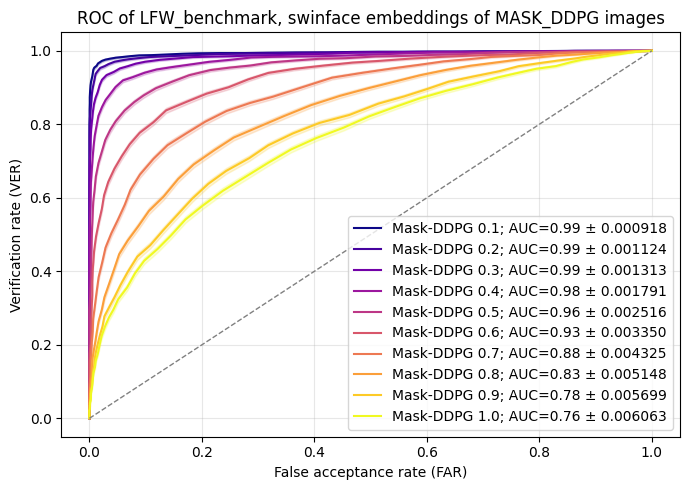

In [16]:
csv_files = [#pairs: path, label
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.1_MaskDDPG.csv','Mask-DDPG 0.1'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.2_MaskDDPG.csv','Mask-DDPG 0.2'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.3_MaskDDPG.csv','Mask-DDPG 0.3'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.4_MaskDDPG.csv','Mask-DDPG 0.4'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.5_MaskDDPG.csv','Mask-DDPG 0.5'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.6_MaskDDPG.csv','Mask-DDPG 0.6'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.7_MaskDDPG.csv','Mask-DDPG 0.7'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.8_MaskDDPG.csv','Mask-DDPG 0.8'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.9_MaskDDPG.csv','Mask-DDPG 0.9'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_1.0_MaskDDPG.csv','Mask-DDPG 1.0'),
]
plot_single_roc_with_uncertainty(csv_files,'ROC of LFW_benchmark, swinface embeddings of MASK_DDPG images', n_bootstrap=1000)

Bootstrapping Progress: 100%|██████████| 1000/1000 [00:13<00:00, 73.50it/s]


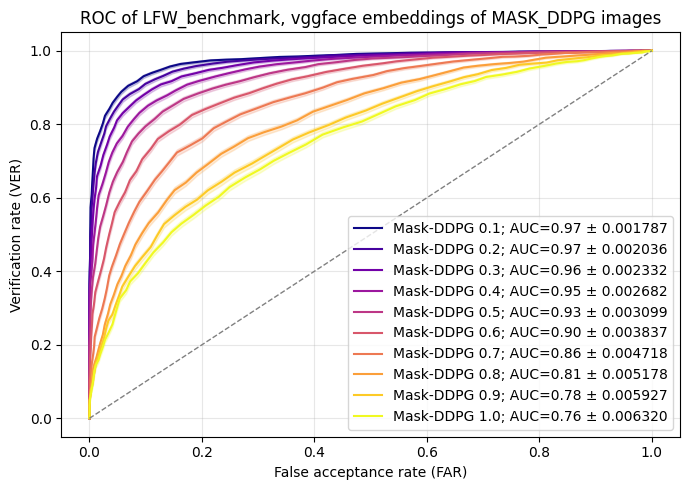

In [17]:
# Set the directory path for your CSV files
csv_files = [#pairs: path, label
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.1_MaskDDPG.csv','Mask-DDPG 0.1'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.2_MaskDDPG.csv','Mask-DDPG 0.2'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.3_MaskDDPG.csv','Mask-DDPG 0.3'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.4_MaskDDPG.csv','Mask-DDPG 0.4'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.5_MaskDDPG.csv','Mask-DDPG 0.5'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.6_MaskDDPG.csv','Mask-DDPG 0.6'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.7_MaskDDPG.csv','Mask-DDPG 0.7'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.8_MaskDDPG.csv','Mask-DDPG 0.8'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.9_MaskDDPG.csv','Mask-DDPG 0.9'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_1.0_MaskDDPG.csv','Mask-DDPG 1.0'),
]
plot_single_roc_with_uncertainty(csv_files,'ROC of LFW_benchmark, vggface embeddings of MASK_DDPG images', n_bootstrap=1000)

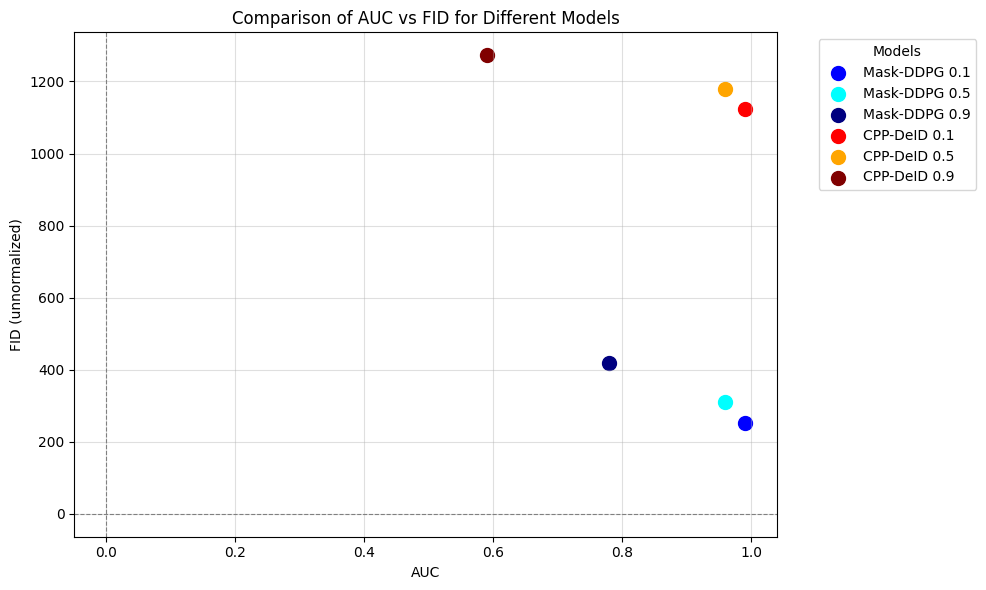

In [3]:
methods = [

    "Mask-DDPG 0.1", "Mask-DDPG 0.5", "Mask-DDPG 0.9",

    "CPP-DeID 0.1", "CPP-DeID 0.5", "CPP-DeID 0.9"

]

auc_values = [0.99, 0.96, 0.78, 0.99, 0.96, 0.59]

fid_values = [251.04, 310.35, 417.49, 1123.53, 1177.85, 1272.83]



# Plotting with grouped colors for Mask-DDPG and CPP-DeID

plt.figure(figsize=(10, 6))



# Define color palettes for the two groups

mask_ddpg_colors = ["blue", "cyan", "navy"]

cpp_deid_colors = ["red", "orange", "maroon"]



# Assign colors to each model

grouped_colors = {

    "Mask-DDPG 0.1": mask_ddpg_colors[0],

    "Mask-DDPG 0.5": mask_ddpg_colors[1],

    "Mask-DDPG 0.9": mask_ddpg_colors[2],

    "CPP-DeID 0.1": cpp_deid_colors[0],

    "CPP-DeID 0.5": cpp_deid_colors[1],

    "CPP-DeID 0.9": cpp_deid_colors[2]

}



for method, auc, fid in zip(methods, auc_values, fid_values):

    plt.scatter(auc, fid, label=method, color=grouped_colors[method], s=100)



# Customizing the plot

plt.xlabel("AUC")

plt.ylabel("FID (unnormalized)")

plt.title("Comparison of AUC vs FID for Different Models")

plt.axhline(0, color='gray', linewidth=0.8, linestyle="--")

plt.axvline(0, color='gray', linewidth=0.8, linestyle="--")

plt.legend(title="Models", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(alpha=0.4)

plt.tight_layout()



# Display the plot

plt.show()